## 1. Introduction
This notebook demonstrates comprehensive EDA techiniques using a dataset that contains anonymized information from loan applications.

## 2. Data Description
### 2.1 About the dataset
The training dataset containing 44,000 loan applications, is designed for building predictive models to detect fraudulent activity. It includes a mix of applicant demographic data, financial history, loan specifics, and a binary target variables indicating whether an application was flagged as fraudulent.
### 2.2 Description of the variables

The dataset is comprised of the following columns:

#### Identifiers and Metadata

| Variable | Description |
| :--- | :--- |
| **application_id** | A unique identifier for each individual loan application. |
| **customer_id** | A unique identifier for each customer. A single customer may have multiple applications. |
| **application_date** | The date on which the loan application was submitted. |
| **data_batch_id** | An identifier for the data processing batch this record belongs to. |

#### Loan Characteristics

| Variable | Description |
| :--- | :--- |
| **loan_amount_requested** | The principal amount of the loan requested by the applicant. |
| **loan_amount_usd** | The requested loan amount converted to US Dollars for standardization. |
| **loan_tenure_months** | The duration of the loan repayment period in months. |
| **interest_rate_offered** | The annual interest rate offered for the loan. |
| **purpose_of_loan** | The stated reason for seeking the loan. |
| **loan_type_\*** | A set of binary columns indicating the specific type of loan product. |

#### Applicant Financial Profile

| Variable | Description |
| :--- | :--- |
| **employment_status** | The applicant's current employment situation. |
| **monthly_income** | The applicant's stated gross monthly income. |
| **yearly_income** | The applicant's stated gross annual income. |
| **annual_bonus** | The applicant's declared annual bonus amount. |
| **cibil_score** | A credit score (e.g., from CIBIL) representing the applicant's creditworthiness and history. **Higher scores indicate better credit health.** |
| **existing_emis_monthly** | The total amount of Equated Monthly Installments (EMIs) the applicant is currently paying for other existing loans. |
| **debt_to_income_ratio** | This ratio helps assess an applicant's ability to manage monthly payments. |
| **credit_utilization_ratio** | The ratio of the applicant's outstanding credit card debt to their total credit card limit. |

#### Applicant Demographics and Personal Information

| Variable | Description |
| :--- | :--- |
| **applicant_age** | The age of the applicant in years at the time of application. |
| **gender_\*** | A set of one-hot encoded binary columns representing the applicant's gender. |
| **property_ownership_status** | The applicant's housing situation. |
| **residential_address** | The applicant's provided residential address (likely anonymized or generalized). |
| **number_of_dependents** | The number of people financially dependent on the applicant. |

#### Target Variable

| Variable | Description |
| :--- | :--- |
| **fraud_flag** | This is the key target variable for prediction. It's a binary indicator where **1** signifies a fraudulent application and **0** signifies a legitimate application. |

## 3. Setup
The setup involves importing all requisite libraries:

In [1]:

import numpy as np
import pandas as pd
import seaborn as sns
import warnings
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter, FuncFormatter
import matplotlib.ticker as mtick
import matplotlib.dates as mdates
import seaborn as sns
import missingno as msno
from scipy import stats 
from scipy.stats import ttest_ind
from IPython.display import display
warnings.filterwarnings('ignore')

And establishing a consistent aesthetic for the graphical outputs:

In [2]:
plt.style.use('bmh')
sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (12, 6)
RANDOM_STATE = 42

## 4. Data Loading
Load the train dataset containing loan application and fraud data.

In [3]:
df = pd.read_csv('train.csv')

## 5. Dataset Overview and Quality Assessment
Showing the first rows of the dataset:

In [4]:
print("First 5 rows:")
df.head()

First 5 rows:


,Unnamed: 0,application_id,customer_id,application_date,loan_amount_requested,loan_tenure_months,interest_rate_offered,purpose_of_loan,employment_status,monthly_income,cibil_score,existing_emis_monthly,debt_to_income_ratio,property_ownership_status,residential_address,applicant_age,number_of_dependents,loan_type_Car Loan,loan_type_Education Loan,loan_type_Home Loan,loan_type_Personal Loan,gender_Male,gender_Other,yearly_income,loan_amount_usd,credit_utilization_ratio,annual_bonus,data_batch_id,fraud_flag
0,1363,acde818b-d1cc-4da4-9858-c2155ee2be85,CUST102632,2025-02-19,100000.0,60,11.27,Vehicle Purchase,Self-Employed,NaN,633,1700.0,3.10,Jointly Owned,"288, Borde Ganj, Udupi-974980, Medininagar, Go...",39,4.0,0,1,0,0,0,0,658800.0,108000.0,0.424338,611.79,batch_20250926_A,0
1,45780,75ab4a03-0d02-4ee4-9840-97486f64ec9e,CUST109462,2024-02-09,551000.0,360,12.14,Vehicle Purchase,Retired,47600.0,705,700.0,1.47,Owned,"664, Koshy Chowk, Rajahmundry 550800, Vadodara...",49,1.0,0,0,0,1,1,0,571200.0,595080.0,0.387727,300.12,batch_20250926_A,1
2,48716,f1170d68-b793-46e2-835a-2c1d58be9d9d,CUST105157,2025-05-10,440000.0,240,12.26,Business Expansion,Self-Employed,NaN,750,5000.0,4.07,Rented,"H.No. 756, Solanki Ganj, Asansol-243947, Panch...",26,4.0,0,0,1,0,0,0,1476000.0,475200.0,0.363311,195884.39,batch_20250926_A,0
3,44109,2ccd4175-9bee-464f-b321-22645c778d8e,CUST103892,2024-09-09,1075000.0,12,12.77,Wedding,Business Owner,30000.0,732,6500.0,21.67,Owned,"27/711, Barad Ganj, Bhilai 678823, Karimnagar,...",36,2.0,1,0,0,0,0,0,360000.0,1161000.0,0.743246,9669.89,batch_20250926_A,0
4,13333,645a4f5b-3382-4624-8496-801147ca1bc3,CUST114147,2023-10-14,379000.0,120,10.56,Wedding,Retired,109800.0,711,2000.0,1.82,RENTED,"716, Uppal Zila, Thiruvananthapuram-263026, Ma...",52,4.0,1,0,0,0,0,1,1317600.0,409320.0,0.442568,1646.28,batch_20250926_A,0


### 5.1 Data Shape

In [5]:
print(f"""Shape: {df.shape}
Number of records: {len(df)}
Number of features: {df.shape[1]}
Distinct customers: {df['customer_id'].nunique()}
Distinct applications: {df['application_id'].nunique()}
""")

Shape: (44000, 29)
Number of records: 44000
Number of features: 29
Distinct customers: 17356
Distinct applications: 40778



### 5.2 Data types and basic info
Data Types:

In [6]:
df.dtypes

Unnamed: 0                     int64
application_id                object
customer_id                   object
application_date              object
loan_amount_requested        float64
loan_tenure_months             int64
interest_rate_offered        float64
purpose_of_loan               object
employment_status             object
monthly_income               float64
cibil_score                    int64
existing_emis_monthly        float64
debt_to_income_ratio         float64
property_ownership_status     object
residential_address           object
applicant_age                  int64
number_of_dependents         float64
loan_type_Car Loan             int64
loan_type_Education Loan       int64
loan_type_Home Loan            int64
loan_type_Personal Loan        int64
gender_Male                    int64
gender_Other                   int64
yearly_income                float64
loan_amount_usd              float64
credit_utilization_ratio     float64
annual_bonus                 float64
d

Dataset Info:

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44000 entries, 0 to 43999
Data columns (total 29 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Unnamed: 0                 44000 non-null  int64  
 1   application_id             44000 non-null  object 
 2   customer_id                44000 non-null  object 
 3   application_date           44000 non-null  object 
 4   loan_amount_requested      44000 non-null  float64
 5   loan_tenure_months         44000 non-null  int64  
 6   interest_rate_offered      44000 non-null  float64
 7   purpose_of_loan            44000 non-null  object 
 8   employment_status          44000 non-null  object 
 9   monthly_income             39594 non-null  float64
 10  cibil_score                44000 non-null  int64  
 11  existing_emis_monthly      44000 non-null  float64
 12  debt_to_income_ratio       44000 non-null  float64
 13  property_ownership_status  44000 non-null  obj

Date fields were stored as objects (strings), which limited the ability to perform filtering, sorting, and time-based analyses such as trend detection or seasonality assessment. 

Converting date columns to datetime:

In [8]:
df['application_date'] = pd.to_datetime(df['application_date'])

Column representing the number of dependents contained fractional values, which were not meaningful in this context.

Converting number of dependents to a nullable integer type (Int64):

In [9]:
df['number_of_dependents'] = df['number_of_dependents'].astype('Int64')

These columns were converted to categorical data types because they represent discrete categories or encoded binary features (dummies), rather than continuous numerical values. This ensures correct treatment during exploratory analysis and statistical summaries.

In [10]:
categorical_cols = [
    'purpose_of_loan',
    'employment_status',
    'property_ownership_status'
]

df[categorical_cols] = df[categorical_cols].astype('category')


Reviewed types to identify changes:

In [11]:
df.dtypes

Unnamed: 0                            int64
application_id                       object
customer_id                          object
application_date             datetime64[ns]
loan_amount_requested               float64
loan_tenure_months                    int64
interest_rate_offered               float64
purpose_of_loan                    category
employment_status                  category
monthly_income                      float64
cibil_score                           int64
existing_emis_monthly               float64
debt_to_income_ratio                float64
property_ownership_status          category
residential_address                  object
applicant_age                         int64
number_of_dependents                  Int64
loan_type_Car Loan                    int64
loan_type_Education Loan              int64
loan_type_Home Loan                   int64
loan_type_Personal Loan               int64
gender_Male                           int64
gender_Other                    

### 5.3 Check for duplicated
It is important to note that the customer_id field is expected to contain duplicates, as the same customer may submit multiple loan applications. Therefore, duplicates in this field were considered valid and not indicative of data inconsistencies.

Check duplicates to decide whether deduplication is needed later:

In [12]:
df = df.drop(columns=["Unnamed: 0"])
cols_to_check = ['application_id', 'customer_id']

def duplicate_checked(data, cols):

    duplicate_rows = data.duplicated().sum()
    duplicate_app_ids = data[cols[0]].duplicated().sum()
    duplicate_customer_ids = data[cols[1]].duplicated().sum()

    print(f"Duplicate rows: {duplicate_rows:,}")
    print(f"Duplicate application_id values: {duplicate_app_ids:,} ({duplicate_app_ids / len(data):.1%})")
    print(f"Duplicate customer_id values: {duplicate_customer_ids:,} ({duplicate_customer_ids / len(data):.1%})")

duplicate_checked(df, cols_to_check)

Duplicate rows: 3,054
Duplicate application_id values: 3,222 (7.3%)
Duplicate customer_id values: 26,644 (60.6%)


It was found that the “Unnamed” column was unnecessary and hindered the accurate identification of fully duplicated records. Therefore, this column was removed from the dataset. After its removal, it became possible to identify and eliminate fully duplicated rows, meaning records with identical values across all relevant columns.

Remove fully duplicated rows and review to identify and assess any remaining partial duplicates:

In [13]:
df.drop_duplicates(inplace=True)

duplicate_checked(df, cols_to_check)

Duplicate rows: 0
Duplicate application_id values: 168 (0.4%)
Duplicate customer_id values: 23,590 (57.6%)


Visualizing duplicated values left on application_id:

In [14]:
app_id_duplicated_rows = (
    
    df[df.duplicated(subset="application_id", keep=False)]
        .sort_values("application_id")
)

app_id_duplicated_rows.head()

,application_id,customer_id,application_date,loan_amount_requested,loan_tenure_months,interest_rate_offered,purpose_of_loan,employment_status,monthly_income,cibil_score,existing_emis_monthly,debt_to_income_ratio,property_ownership_status,residential_address,applicant_age,number_of_dependents,loan_type_Car Loan,loan_type_Education Loan,loan_type_Home Loan,loan_type_Personal Loan,gender_Male,gender_Other,yearly_income,loan_amount_usd,credit_utilization_ratio,annual_bonus,data_batch_id,fraud_flag
39345,036a9848-124d-4f9b-b2a7-54892951fdad,CUST108692,2025-01-22,743000.0,12,8.26,Medical Emergency,Retired,63300.0,703,4400.0,6.95,Jointly Owned,"21/73, Sekhon Zila, Udaipur-538308, Berhampur,...",63,2,0,0,0,1,1,0,759600.0,802440.0,0.573369,464.27,batch_20250926_A,1
571,036a9848-124d-4f9b-b2a7-54892951fdad,CUST108692,2025-01-22,743000.0,1349,8.26,Medical Emergency,Retired,63300.0,703,4400.0,6.95,Jointly Owned,"21/73, Sekhon Zila, Udaipur-538308, Berhampur,...",63,2,0,0,0,1,1,0,759600.0,802440.0,0.573369,464.27,batch_20250926_A,1
5361,043cebfa-03f7-4ec6-a1f7-72fae1ee6b66,CUST114680,2023-08-16,146000.0,1376,6.20,Medical Emergency,Salaried,32700.0,746,1100.0,3.36,Jointly Owned,"H.No. 47, Mallick Zila, Udaipur 779183, Aurang...",47,0,0,1,0,0,0,0,392400.0,157680.0,0.754111,2457.73,batch_20250926_A,1
29361,043cebfa-03f7-4ec6-a1f7-72fae1ee6b66,CUST114680,2023-08-16,146000.0,12,6.20,Medical Emergency,Salaried,32700.0,746,1100.0,3.36,Jointly Owned,"H.No. 47, Mallick Zila, Udaipur 779183, Aurang...",47,0,0,1,0,0,0,0,392400.0,157680.0,0.754111,2457.73,batch_20250926_A,1
6357,04904486-8385-4a1e-91b3-7b0d369c724c,CUST110972,2023-09-06,696000.0,1225,8.16,Education,Retired,NaN,707,4700.0,4.91,Jointly Owned,"45, Bumb Street, Surat-708823, Morena, Meghala...",63,1,0,0,0,0,0,1,1149600.0,751680.0,0.490685,20888.09,batch_20250926_A,1


After visualizing the duplicated rows in the application_id column, it was observed that these records differ only in the loan_tenure_months field.
To further investigate this variation, the next step is to analyze the distribution of loan_tenure_months and identify potential outliers that may explain these discrepancies.

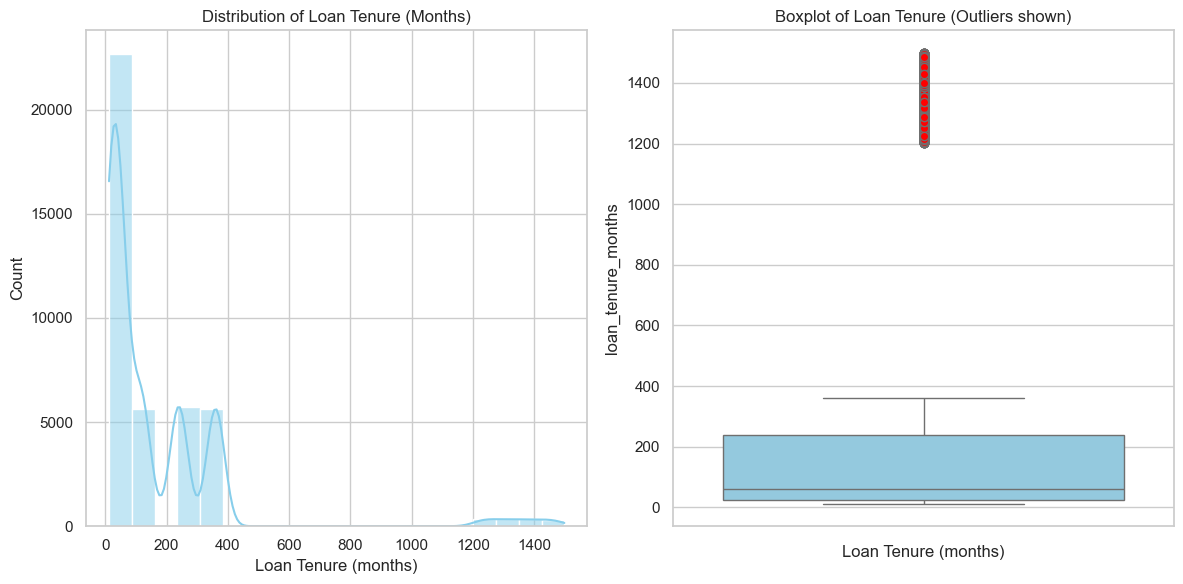

In [15]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))


sns.histplot(df["loan_tenure_months"], bins=20, kde=True, ax=axes[0], color="skyblue")
axes[0].set_title("Distribution of Loan Tenure (Months)")
axes[0].set_xlabel("Loan Tenure (months)")
axes[0].set_ylabel("Count")


sns.boxplot(df["loan_tenure_months"], ax=axes[1], color="skyblue", fliersize=6, flierprops=dict(marker='o', markerfacecolor='red', markersize=6))
axes[1].set_title("Boxplot of Loan Tenure (Outliers shown)")
axes[1].set_xlabel("Loan Tenure (months)")

plt.tight_layout()
plt.show()

The distribution of loan tenure is highly right-skewed, most of the data is concentrated below 400 months, while the whiskers extend slightly beyond this range. The points above the upper whisker indicate outliers, corresponding to unusually long loan tenures. These extreme values could distort analyses if not addressed. Overall, the plots support the decision to apply the IQR method to remove high-tenure outliers.

In [16]:
Q1 = df["loan_tenure_months"].quantile(0.25)
Q3 = df["loan_tenure_months"].quantile(0.75)
IQR = Q3 - Q1
upper_limit = Q3 + 1.5 * IQR

outliers = df[df["loan_tenure_months"] > upper_limit]
print(f"{len(outliers)} outliers found in loan_tenure_months column.")

df_filtered = df[df["loan_tenure_months"] <= upper_limit]

1309 outliers found in loan_tenure_months column.


The first ($Q_1$) and third ($Q_3$) quartiles were calculated to determine the Interquartile Range ($IQR$), and an upper threshold was set at $Q_3 + 1.5 \times IQR$. Loan tenures exceeding this threshold were identified as statistical outliers, and the total number of outliers was recorded.

After identifying outliers, the dataset was filtered to create a cleaned version (df_filtered) containing only loan tenures within the acceptable range. This approach allowed for both the retention of the original data for reference and the preparation of a clean dataset for further analysis.

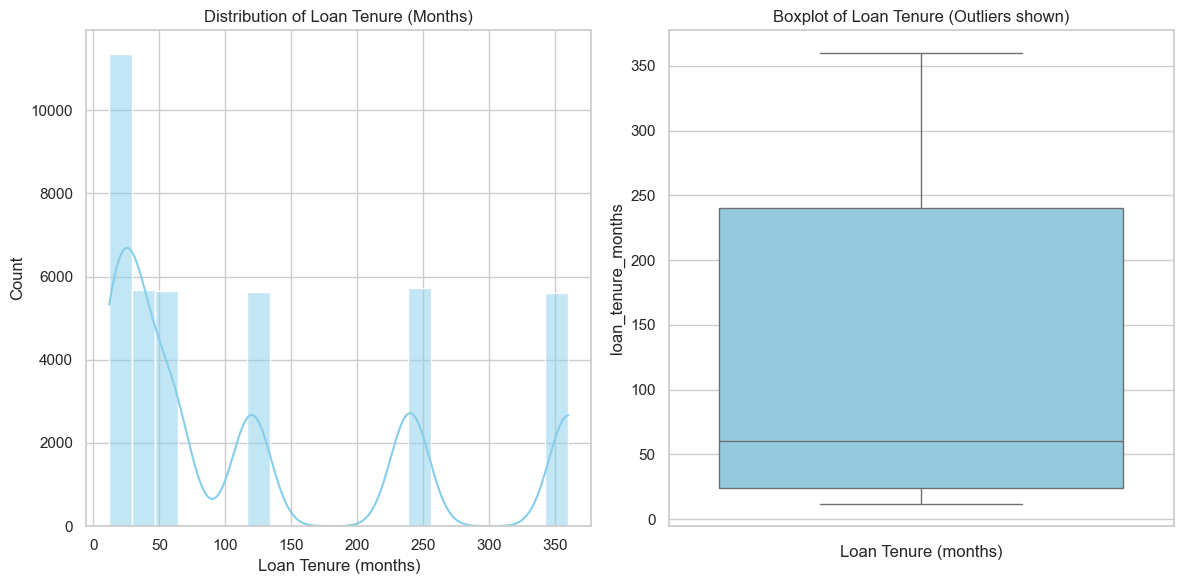

In [17]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))


sns.histplot(df_filtered["loan_tenure_months"], bins=20, kde=True, ax=axes[0], color="skyblue")
axes[0].set_title("Distribution of Loan Tenure (Months)")
axes[0].set_xlabel("Loan Tenure (months)")
axes[0].set_ylabel("Count")


sns.boxplot(df_filtered["loan_tenure_months"], ax=axes[1], color="skyblue", fliersize=6, flierprops=dict(marker='o', markerfacecolor='red', markersize=6))
axes[1].set_title("Boxplot of Loan Tenure (Outliers shown)")
axes[1].set_xlabel("Loan Tenure (months)")

plt.tight_layout()
plt.show()

To visually confirm the filtering process, boxplots were generated before and after removing the outliers.

### 5.3 Check for missing values
Missing values:

In [18]:
missing_values = df_filtered.isnull().sum()
missing_percent = 100 * missing_values / len(df_filtered)
missing_percent = missing_percent.round(2)

missing_summary = pd.DataFrame({
    "Missing Count": missing_values,
    "Missing Percentage (%)": missing_percent
})

missing_summary = missing_summary[missing_summary["Missing Count"] > 0]

if missing_summary.empty:
    print("No missing values found in the dataset.")
else:
    print("Columns with missing values:\n")
    print(missing_summary)
    total_missing = missing_values.sum()
    total_cells = df_filtered.size  
    total_missing_percent = round(100 * total_missing / total_cells, 2)
    print(f"\nTotal cells with missing values: {total_missing}")
    print(f"Total cells missing percentage: {total_missing_percent}%")



Columns with missing values:

                      Missing Count  Missing Percentage (%)
monthly_income                 3970                   10.02
number_of_dependents           3996                   10.08

Total cells with missing values: 7966
Total cells missing percentage: 0.72%


Visualizing missing data, the white gaps in the matrix represent missing values for each column:

<Axes: >

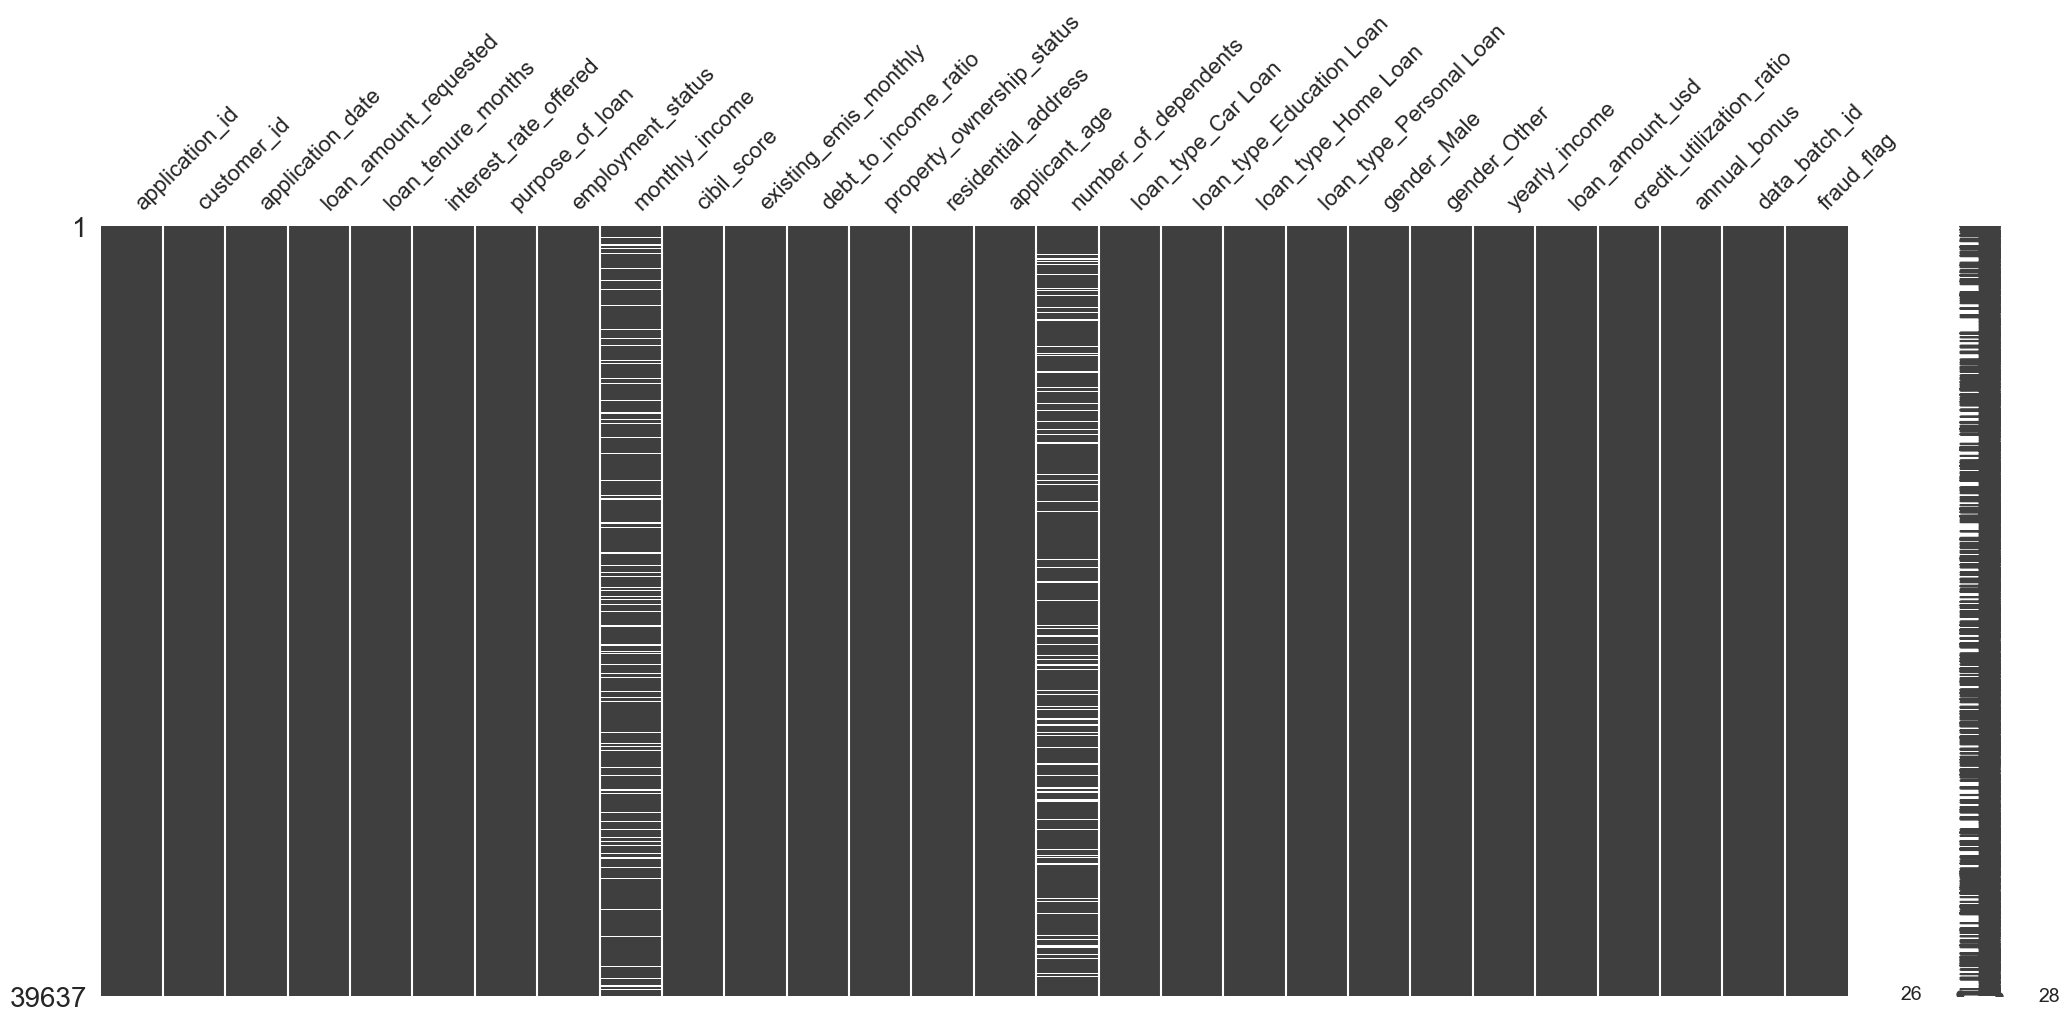

In [19]:
msno.matrix(df_filtered) 

The matrix view clearly shows that the columns nullity is not perfectly correlated. The majority of the dataset remains 100% complete.

In [20]:
total_rows = len(df_filtered)

rows_with_na = df_filtered.dropna(how='any')
rows_to_remove = total_rows - len(rows_with_na)

percent_to_remove = round(100 * rows_to_remove / total_rows, 2)

print(f"Rows to remove: {rows_to_remove}")
print(f"Percentage of dataset: {percent_to_remove}%")
print(f"Missing values in pairs: {total_missing - rows_to_remove}")

Rows to remove: 7565
Percentage of dataset: 19.09%
Missing values in pairs: 401


The total missing percentage considers all values in the dataset. Although it shows only 0.72%, if we decide to handle these missing values by dropping them, it would require removing the entire row. There are 7966 missing values in total, but some missing values appear in pairs on the same row in 401 cases. Considering that removing all 7,565 values would impact 19.09% of the dataset, which it is not be the best approach for handling the missing values in that case. Alternative methods for handling missing data, such as imputation, forward/backward fill, or using model-based techniques, could be considered to minimize data loss.

## 6. Descriptive Statistics
### 6.1 Numerical Variables Summary

In [21]:
num_cols = [
    col for col in df_filtered.select_dtypes(include=['number']).columns
    if df_filtered[col].nunique() > 2  # remove dummies e flags binárias
]

numeric_summary = (
    df_filtered[num_cols]
    .describe()
    .T
    .assign(skew=lambda x: df_filtered[num_cols].skew())
    .round(2)
)

print(numeric_summary)

                            count           mean            std       min  \
loan_amount_requested     39637.0  515522.315009  327827.552635  100000.0   
loan_tenure_months        39637.0     121.553094     121.423618      12.0   
interest_rate_offered     39637.0      10.526348       1.993901      5.27   
monthly_income            35667.0   50747.150027   23841.176474   10000.0   
cibil_score               39637.0     699.031208      50.108209     484.0   
existing_emis_monthly     39637.0    3057.060322     1893.44771       0.0   
debt_to_income_ratio      39637.0       8.555975       9.582105       0.0   
applicant_age             39637.0      43.063224      12.967522      21.0   
number_of_dependents      35641.0       2.012682       1.406298       0.0   
yearly_income             39637.0   609078.72947  285960.892929  120000.0   
loan_amount_usd           39637.0  555054.960769  297476.911981  108000.0   
credit_utilization_ratio  39637.0       0.498438       0.197621       0.0   

### 6.2 Categorical Variables Summary

In [22]:
print(df_filtered.describe(include="category").to_string())

           purpose_of_loan employment_status property_ownership_status
count                39637             39637                     39637
unique                   7                 6                         6
top     Debt Consolidation          Salaried                    Rented
freq                  5723              6773                      9388


In [23]:
dummy_cols = [
    'loan_type_Car Loan', 'loan_type_Education Loan', 'loan_type_Home Loan',
    'loan_type_Personal Loan', 'gender_Male', 'gender_Other', 'fraud_flag'
]

dummy_summary = (
    df_filtered[dummy_cols]
    .agg(['sum', 'count'])  # nomes corretos
    .T
    .assign(
        total=lambda x: x['count'],
        count_1=lambda x: x['sum'],
        count_0=lambda x: x['count'] - x['sum'],
        percent_1=lambda x: (x['count_1'] / x['total'] * 100).round(2),
        percent_0=lambda x: (x['count_0'] / x['total'] * 100).round(2)
    )[["total", "count_0", "percent_0", "count_1", "percent_1"]]
)

print(dummy_summary)

                          total  count_0  percent_0  count_1  percent_1
loan_type_Car Loan        39637    31735      80.06     7902      19.94
loan_type_Education Loan  39637    31721      80.03     7916      19.97
loan_type_Home Loan       39637    31624      79.78     8013      20.22
loan_type_Personal Loan   39637    31652      79.85     7985      20.15
gender_Male               39637    26670      67.29    12967      32.71
gender_Other              39637    26202      66.10    13435      33.90
fraud_flag                39637    34286      86.50     5351      13.50


The dataset shows 13.5% fraudulent applications versus 86.5% legitimate ones.

## 7. Univariable Distribution Analysis
For the univariate analysis we will consider one variable at a time, and distinguish between numerical and categorical variables.

### 7.1 Distribution plots for continuous variables (density-normalized histograms)

Each subplot shows a density-normalized histogram for a continuous variable. The `stat="density"` option scales each histogram so that the total area equals 1; therefore the bar heights represent probability density (probability per unit on the x-axis). Because `common_norm=False`, each group's histogram is normalized independently, allowing direct comparison of distribution shapes regardless of group size.

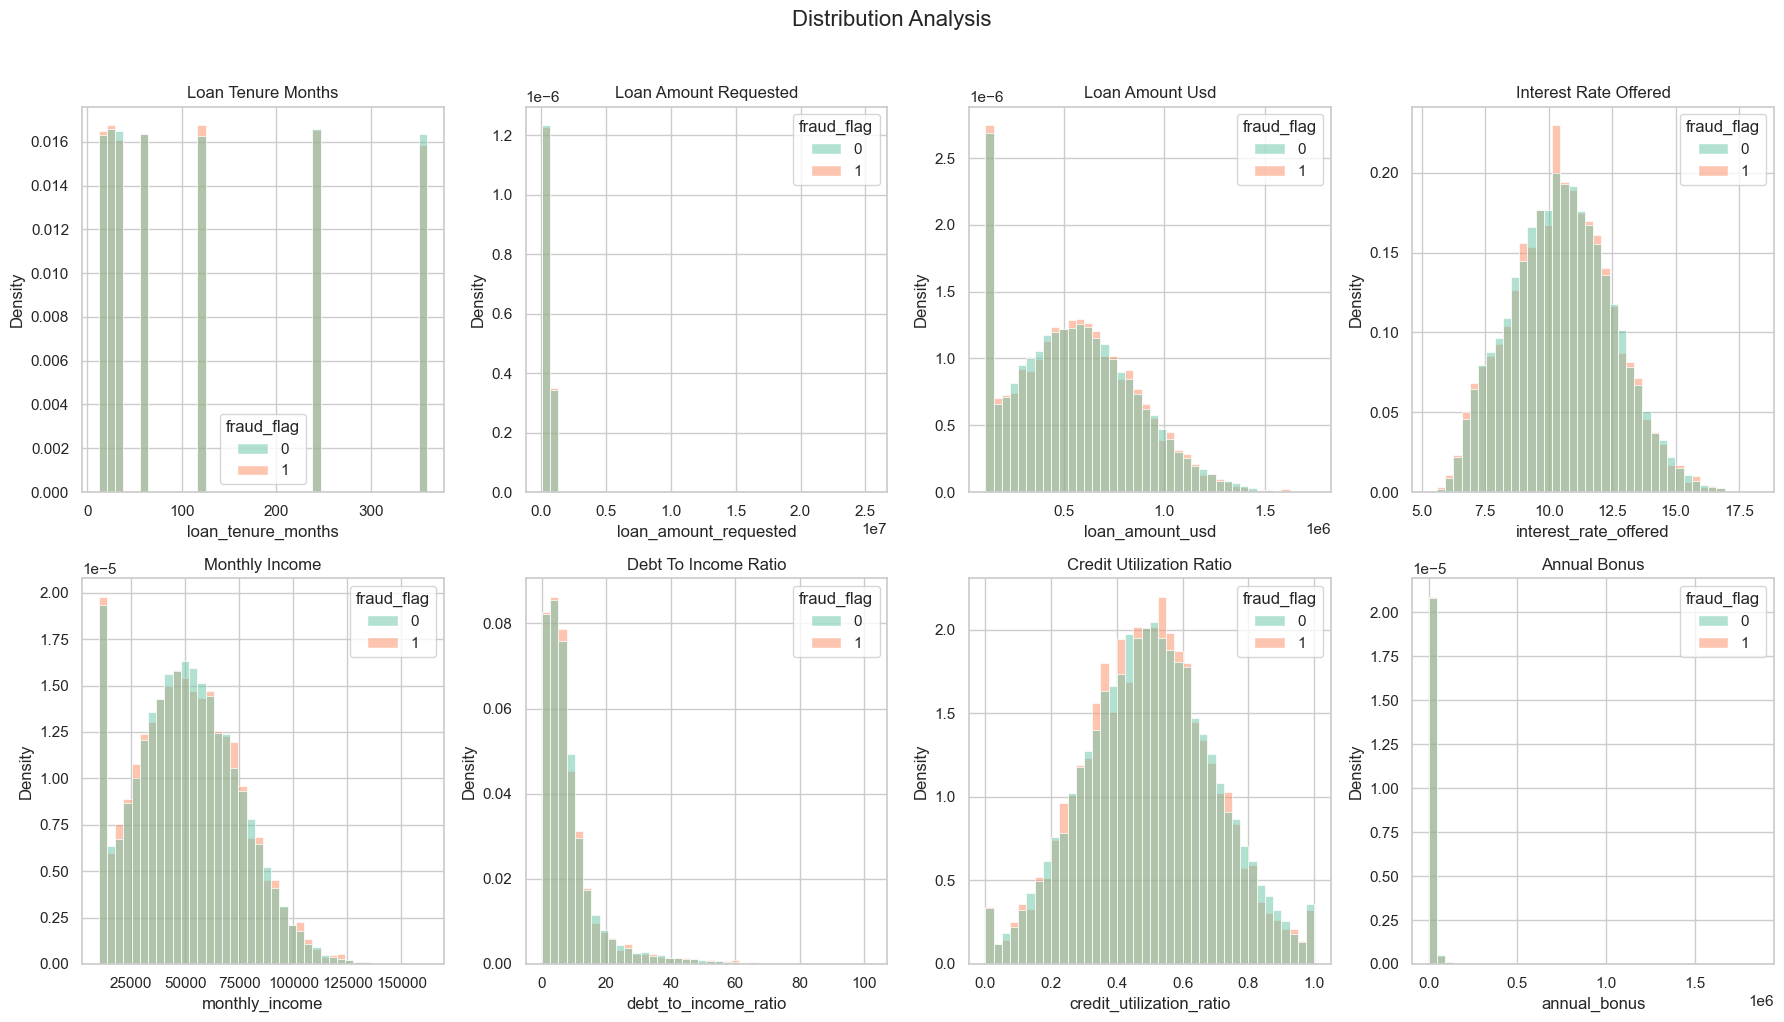

In [24]:
continuous_features = [
    "loan_tenure_months",
    "loan_amount_requested",
    "loan_amount_usd",
    "interest_rate_offered",
    "monthly_income",
    "debt_to_income_ratio",
    "credit_utilization_ratio",
    "annual_bonus",
    "cibil_score",
    "applicant_age",
    "existing_emis_monthly",
    "yearly_income"
]

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
fig.suptitle('Distribution Analysis', fontsize=16, y=1.02)
for ax, col in zip(axes.flat, continuous_features):
    sns.histplot(
        data=df_filtered,
        x=col,
        bins=40,
        hue="fraud_flag",
        stat="density",
        common_norm=False,
        palette="Set2",
        ax=ax
    )
    ax.set_title(col.replace("_", " " ).title())
plt.tight_layout()
plt.show()

### 7.2 Boxplots for Outlier Analisis

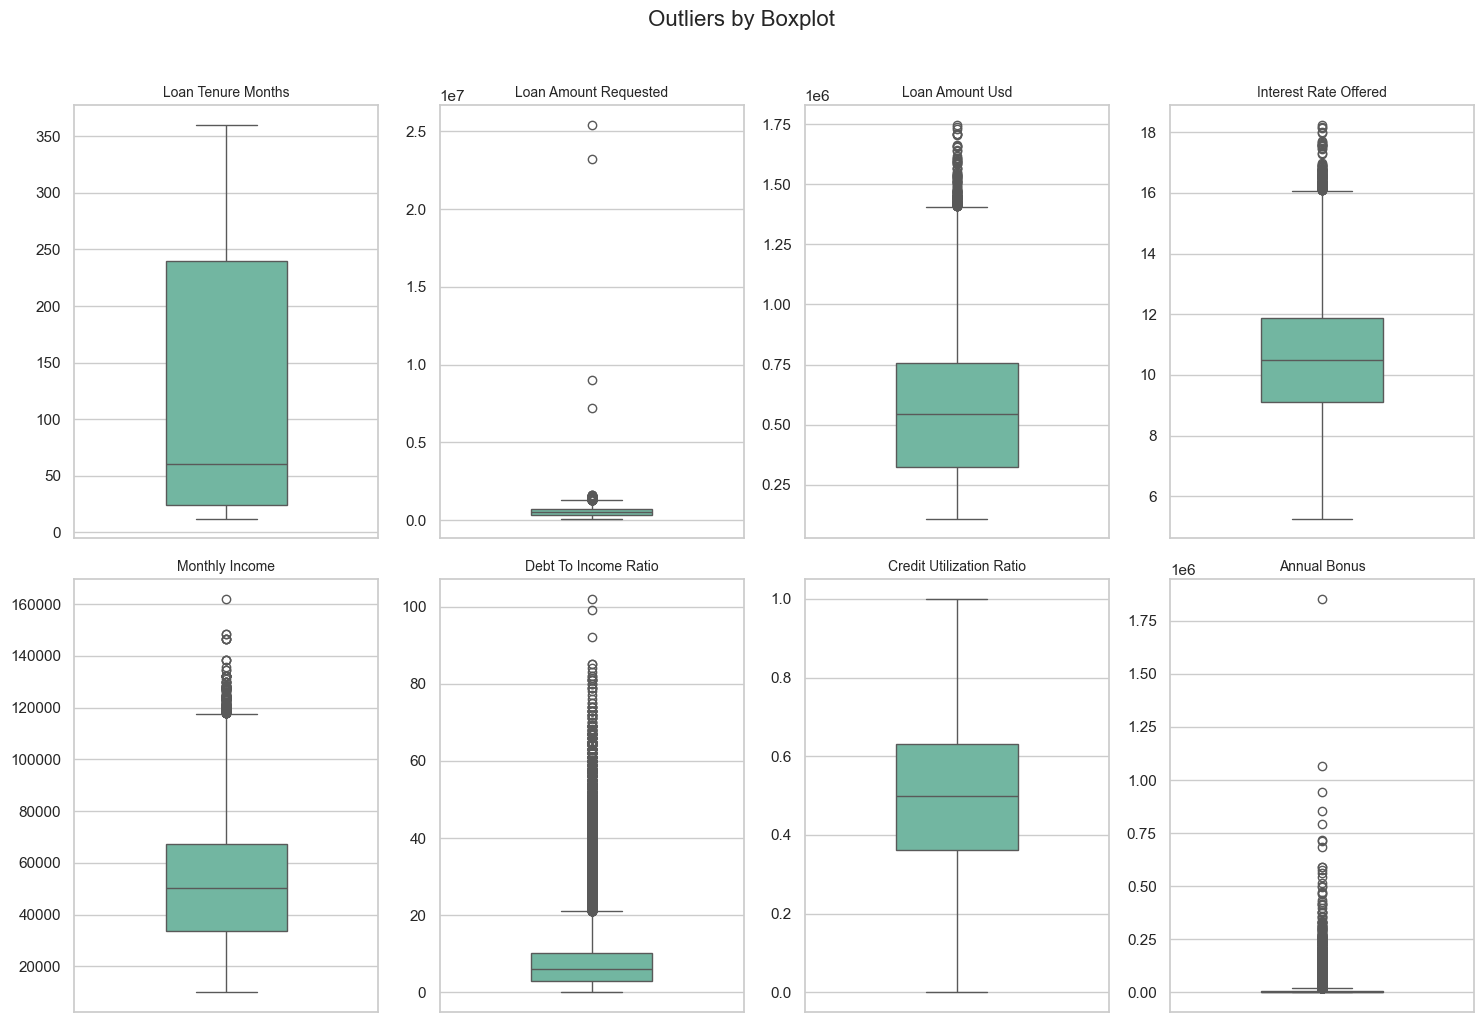

In [25]:
sns.set_theme(style="whitegrid", palette="Set1")

continuous_features = [
    "loan_tenure_months",
    "loan_amount_requested",
    "loan_amount_usd",
    "interest_rate_offered",
    "monthly_income",
    "debt_to_income_ratio",
    "credit_utilization_ratio",
    "annual_bonus",
    "cibil_score",
    "applicant_age",
    "existing_emis_monthly",
    "yearly_income"
]

fig, axes = plt.subplots(2, 4, figsize=(15, 10))
fig.suptitle('Outliers by Boxplot', fontsize=16, y=1.02)

for ax, col in zip(axes.flatten(), continuous_features):
    sns.boxplot(
        data=df_filtered,
        y=col,
        ax=ax,
        width=0.4,
        color=sns.color_palette("Set2")[0],  
        showfliers=True,  
    )
    ax.set_title(col.replace('_', ' ').title(), fontsize=10)
    ax.set_xlabel('')
    ax.set_ylabel('')

plt.tight_layout()
plt.show()


- Loan Amount Requested & Loan Amount USD:
    Values up to tens of millions. These outliers strongly influence the distribution.

- Debt to Income Ratio:
    Extremely high ratios (above 80–100) indicate potential misreported income or unrealistic debt levels, which could distort credit risk metrics.

- Monthly Income & Annual Bonus:
    A few individuals report very high income and bonuses. Further validation is recommended, especially when bonuses exceed several times the monthly salary.

- Interest Rate Offered:
    Most rates cluster between 8–12%, but higher outliers (>16%) may correspond to high-risk borrowers or special loan products.

- Loan Tenure Months:
    Some loans exceed 300 months (25 years). These long tenures could be mortgage-type loans.

### 7.3 Distribution analysis for categorical variables

In [26]:
dummy_cols = [
    'loan_type_Car Loan', 'loan_type_Education Loan', 'loan_type_Home Loan',
    'loan_type_Personal Loan', 'gender_Male', 'gender_Other', 'fraud_flag'
]

categorical_cols = [
    c for c in df_filtered.select_dtypes(include=['category']).columns
    if c not in dummy_cols
]

all_cats = dummy_cols + categorical_cols

for col in all_cats:
    print(f"Distribution ({col}):")
    counts = df_filtered[col].value_counts(dropna=False)
    percentages = df_filtered[col].value_counts(normalize=True, dropna=False) * 100
    summary_df = pd.DataFrame({
        'Count': counts,
        'Percentage': percentages.round(1)
    })
    print(summary_df)
    print('-' * 50)



Distribution (loan_type_Car Loan):
                    Count  Percentage
loan_type_Car Loan                   
0                   31735        80.1
1                    7902        19.9
--------------------------------------------------
Distribution (loan_type_Education Loan):
                          Count  Percentage
loan_type_Education Loan                   
0                         31721        80.0
1                          7916        20.0
--------------------------------------------------
Distribution (loan_type_Home Loan):
                     Count  Percentage
loan_type_Home Loan                   
0                    31624        79.8
1                     8013        20.2
--------------------------------------------------
Distribution (loan_type_Personal Loan):
                         Count  Percentage
loan_type_Personal Loan                   
0                        31652        79.9
1                         7985        20.1
---------------------------------------

### 7.4 Normalize categorical columns by standardizing text formatting

In [27]:
categCols = [
    'purpose_of_loan', 
    'employment_status', 
    'property_ownership_status'
]

for column in categCols:
    df_filtered.loc[:, column] = (
        df_filtered.loc[: , column]
        .astype(str)        
        .str.strip()
        .str.title()
        .astype('category') 
    )

Check normalized categories

In [28]:
dummy_cols = [
    'loan_type_Car Loan', 'loan_type_Education Loan', 'loan_type_Home Loan',
    'loan_type_Personal Loan', 'gender_Male', 'gender_Other', 'fraud_flag'
]

categorical_cols = [
    c for c in df_filtered.select_dtypes(include=['category']).columns
    if c not in dummy_cols
]

all_cats = dummy_cols + categorical_cols

for col in all_cats:
    print(f"Distribution ({col}):")
    counts = df_filtered[col].value_counts(dropna=False)
    percentages = df_filtered[col].value_counts(normalize=True, dropna=False) * 100
    summary_df = pd.DataFrame({
        'Count': counts,
        'Percentage': percentages.round(1)
    })
    print(summary_df)
    print('-' * 50)

Distribution (loan_type_Car Loan):
                    Count  Percentage
loan_type_Car Loan                   
0                   31735        80.1
1                    7902        19.9
--------------------------------------------------
Distribution (loan_type_Education Loan):
                          Count  Percentage
loan_type_Education Loan                   
0                         31721        80.0
1                          7916        20.0
--------------------------------------------------
Distribution (loan_type_Home Loan):
                     Count  Percentage
loan_type_Home Loan                   
0                    31624        79.8
1                     8013        20.2
--------------------------------------------------
Distribution (loan_type_Personal Loan):
                         Count  Percentage
loan_type_Personal Loan                   
0                        31652        79.9
1                         7985        20.1
---------------------------------------

### 7.4 Analises of encoded categorical features

Assess the quality of loan type encoding by checking for missing, valid, or multiple type selections.

In [29]:
loan_dummies = [
    'loan_type_Car Loan', 'loan_type_Education Loan',
    'loan_type_Home Loan', 'loan_type_Personal Loan'
]

df_filtered.loc[:, 'loan_type_sum'] = df_filtered[loan_dummies].sum(axis=1)

summary = df_filtered['loan_type_sum'].value_counts()

print("Loan type encoding summary:\n")
print(f"Exactly one loan type selected: {summary.get(1, 0)} rows")
print(f"No loan type selected: {summary.get(0, 0)} rows")
print(f"Multiple loan types selected: {summary[summary.index > 1].sum()} rows\n")

Loan type encoding summary:

Exactly one loan type selected: 31816 rows
No loan type selected: 7821 rows
Multiple loan types selected: 0 rows



Generate a crosstab to explore the correlation between loan types and their purposes.

In [30]:
def loan_type_label(row):
    if row['loan_type_Car Loan'] == 1:
        return 'Car'
    elif row['loan_type_Education Loan'] == 1:
        return 'Education'
    elif row['loan_type_Home Loan']==1:
        return 'Home'
    elif row['loan_type_Personal Loan']==1:
        return 'Personal'
    else:
        return 'Other'

df_filtered['loan_type_label'] = df_filtered.apply(loan_type_label, axis=1)

pd.crosstab(df_filtered['loan_type_label'], df_filtered['purpose_of_loan'])

purpose_of_loan,Business Expansion,Debt Consolidation,Education,Home Renovation,Medical Emergency,Vehicle Purchase,Wedding
loan_type_label,,,,,,,
Car,1094,1163,1135,1122,1135,1132,1121
Education,1060,1166,1211,1120,1134,1112,1113
Home,1166,1113,1140,1166,1119,1124,1185
Other,1158,1145,1078,1122,1143,1076,1099
Personal,1130,1136,1094,1155,1137,1143,1190


Assess the quality of gender encoding by checking for missing, valid, or multiple gender selections.

In [31]:
gender_dummies = ['gender_Male', 'gender_Other']

df_filtered.loc[:, 'gender_sum'] = df_filtered[gender_dummies].sum(axis=1)

gender_counts = df_filtered['gender_sum'].value_counts().sort_index()

print("Gender encoding summary:\n")
print(f"Exactly one gender selected: {gender_counts.get(1, 0)} rows")
print(f"No gender selected: {gender_counts.get(0, 0)} rows")
print(f"Multiple genders selected: {gender_counts.get(2, 0)} rows")

Gender encoding summary:

Exactly one gender selected: 26402 rows
No gender selected: 13235 rows
Multiple genders selected: 0 rows


## 8. Bivariate Analysis

### 8.1 Pairplots

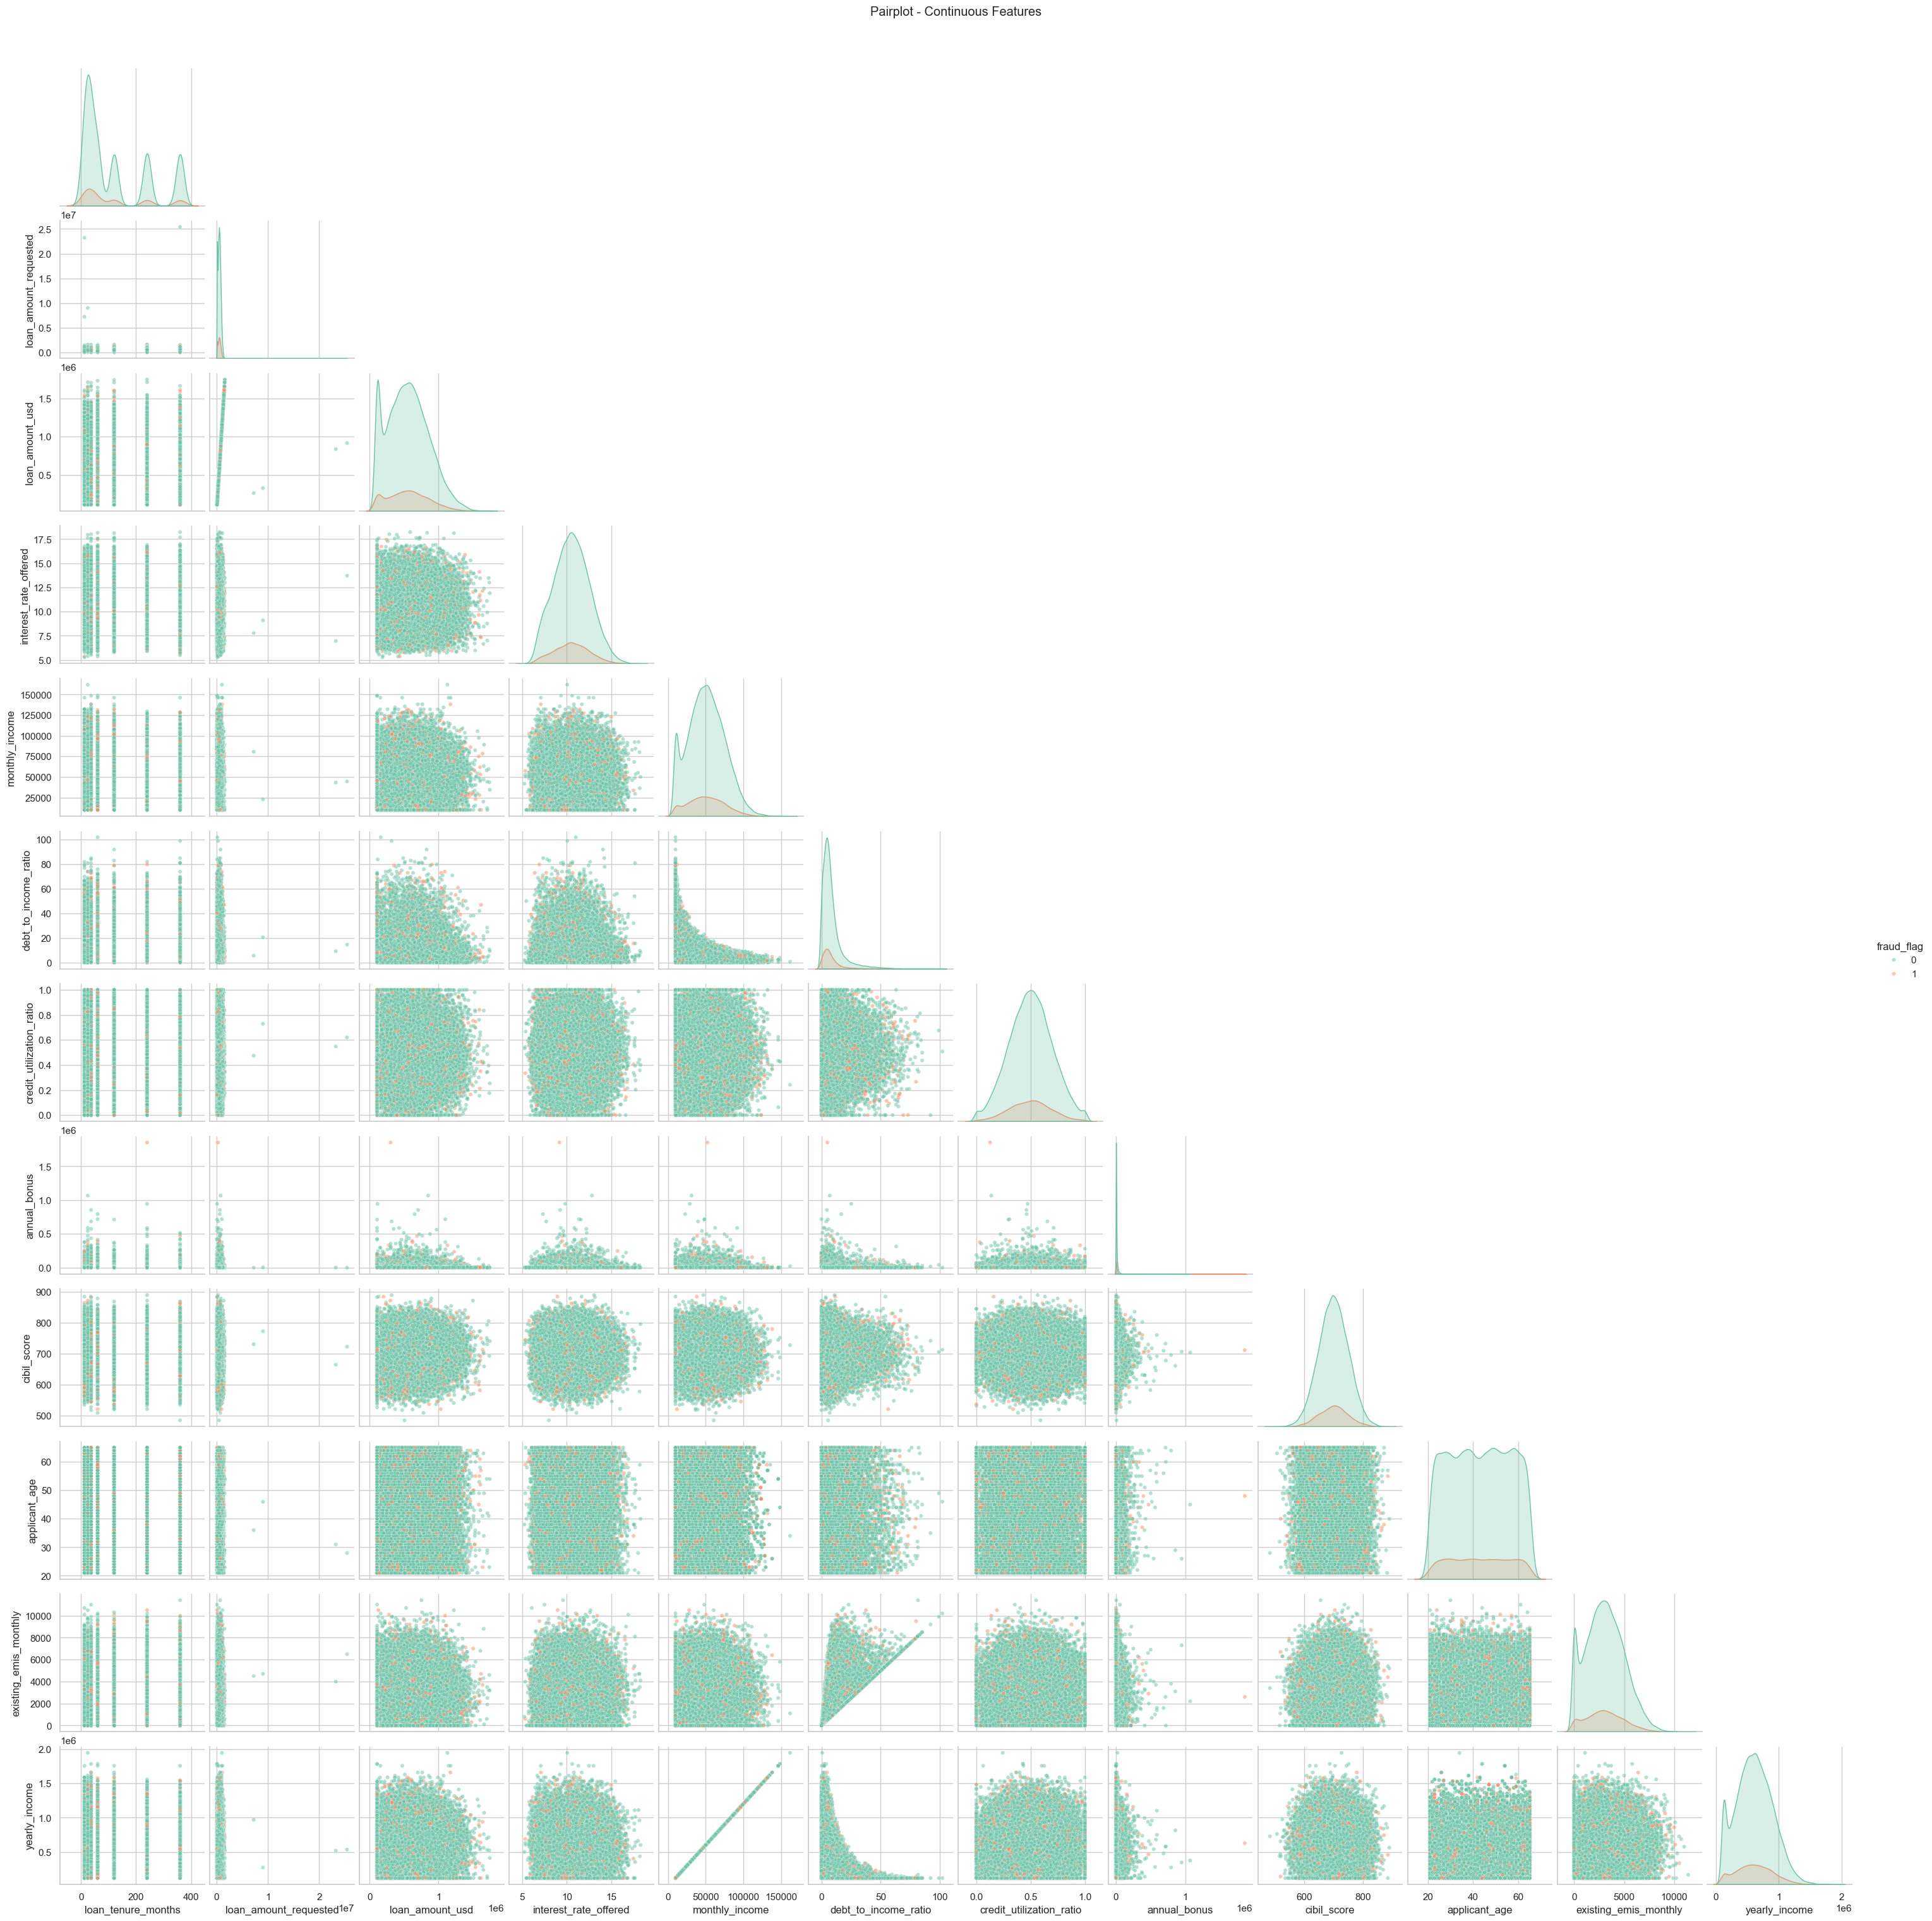

In [32]:
df_pair = df_filtered.copy()

pair_features = [
    "loan_tenure_months",
    "loan_amount_requested",
    "loan_amount_usd",
    "interest_rate_offered",
    "monthly_income",
    "debt_to_income_ratio",
    "credit_utilization_ratio",
    "annual_bonus",
    "cibil_score",
    "applicant_age",
    "existing_emis_monthly",
    "yearly_income"
]

sns.pairplot(
    data=df_pair,
    vars=pair_features,
    hue="fraud_flag",
    palette="Set2",
    corner=True,       
    plot_kws={"alpha": 0.5, "s": 20}  
)

plt.suptitle("Pairplot - Continuous Features", y=1.02)
plt.show()

### 8.2 Chi-Square Test

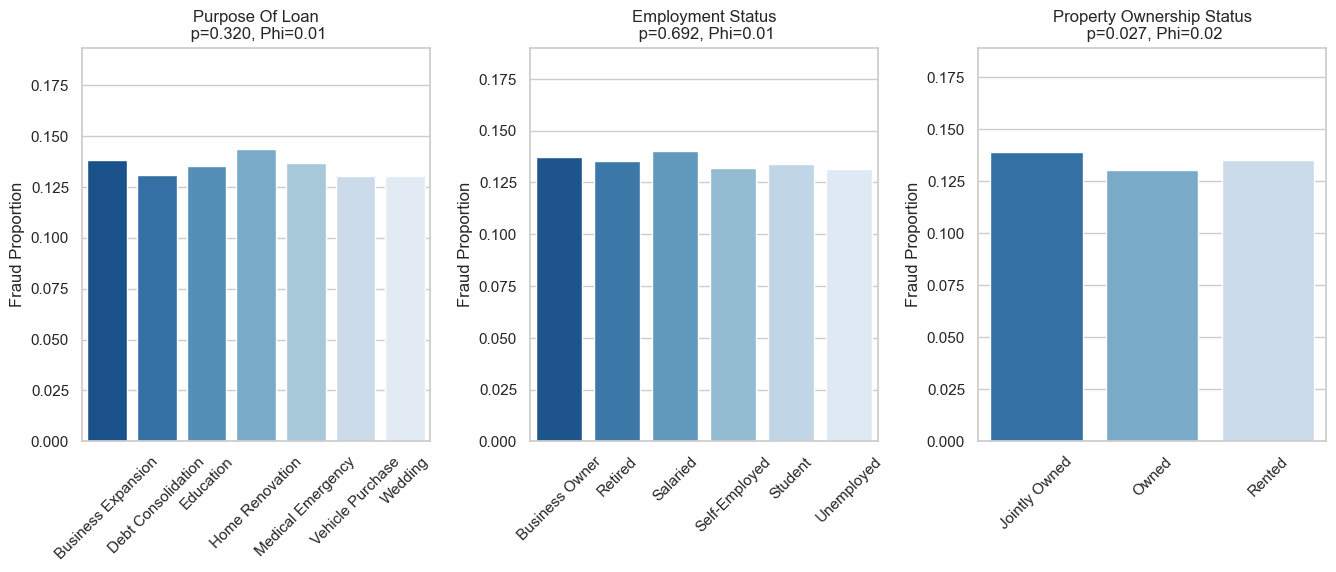

In [33]:
from scipy.stats import chi2_contingency
plt.figure(figsize=(18, 10))
sns.set_theme(style="whitegrid")

for i, col in enumerate(categCols):
    # Contingency table
    contig_table = pd.crosstab(df[col], df_filtered['fraud_flag'])
    
    # Qui-square
    chi2, p, dof, expected = chi2_contingency(contig_table)
    phi = np.sqrt(chi2 / df_filtered.shape[0])
    
    # Frauds Proportion
    prop_df = df_filtered.groupby(col)['fraud_flag'].mean().reset_index()
    
    # Subplotting
    ax = plt.subplot(2, 4, i+1)  # i+1 porque subplot index começa em 1
    sns.barplot(x=col, y='fraud_flag', data=prop_df, palette='Blues_r', ax=ax, hue=col, legend=False)
    
    ax.set_title(f'{col.replace("_"," ").title()}\n p={p:.3f}, Phi={phi:.2f}', fontsize=12)
    ax.set_ylabel('Fraud Proportion')
    ax.set_xlabel('')
    ax.set_ylim(0, prop_df['fraud_flag'].max() + 0.05)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

No significant associations between fraud and any categorical variable

Purpose of Loan:
- p-value = 0.263 >> 0.05 (not significant)
- Phi = 0.01 (negligible effect size)
- Interpretation: Fraud is equally distributed across all loan purposes (Business 
  Expansion, Debt Consolidation, Education, etc.)

Employment Status:
- p-value = 0.856 >> 0.05 (not significant)  
- Phi = 0.01 (negligible effect size)
- Interpretation: Fraudsters come from all employment categories equally - no 
  "high-risk" employment profile exists

Property Ownership Status:
- p-value = 0.064 (marginally significant but > 0.05)
- Phi = 0.02 (still negligible effect)
- Interpretation: Even with the lowest p-value, the effect is practically irrelevant

### 8.3 T-test

In [34]:
fraud_focus_cols = [
    "loan_amount_requested",
    "loan_amount_usd",
    "monthly_income",
    "yearly_income",
    "annual_bonus",
    "existing_emis_monthly",
    "debt_to_income_ratio",
    "credit_utilization_ratio",
    "applicant_age",
    "number_of_dependents",
    "cibil_score"
]

ttest_results_filtered = {}

for col in fraud_focus_cols:
    pos = df_filtered.loc[df_filtered["fraud_flag"] == 1, col].dropna()
    neg = df_filtered.loc[df_filtered["fraud_flag"] == 0, col].dropna()
    if len(pos) > 2 and len(neg) > 2:
        ttest = stats.ttest_ind(pos, neg, equal_var=False)
        ttest_results_filtered[col] = {
            "t_stat": ttest.statistic,
            "p_value": ttest.pvalue
        }

ttest_results_df = pd.DataFrame(ttest_results_filtered).T.sort_values("p_value")
ttest_results_df


,t_stat,p_value
credit_utilization_ratio,-1.510760,0.130893
annual_bonus,-0.659865,0.509364
yearly_income,0.342708,0.731828
number_of_dependents,0.338951,0.734658
loan_amount_requested,-0.239086,0.811045
loan_amount_usd,0.204830,0.837711
applicant_age,0.155003,0.876824
debt_to_income_ratio,0.144323,0.885249
existing_emis_monthly,0.071462,0.943032
cibil_score,0.060514,0.951748


All variables have p-values above 0.05, meaning none of the tested features show a statistically significant difference between fraudulent and non-fraudulent applications.

## 9. Multivariate Analysis

### 9.1 Correlation Matrix
For numerical features we can use correlation matrix

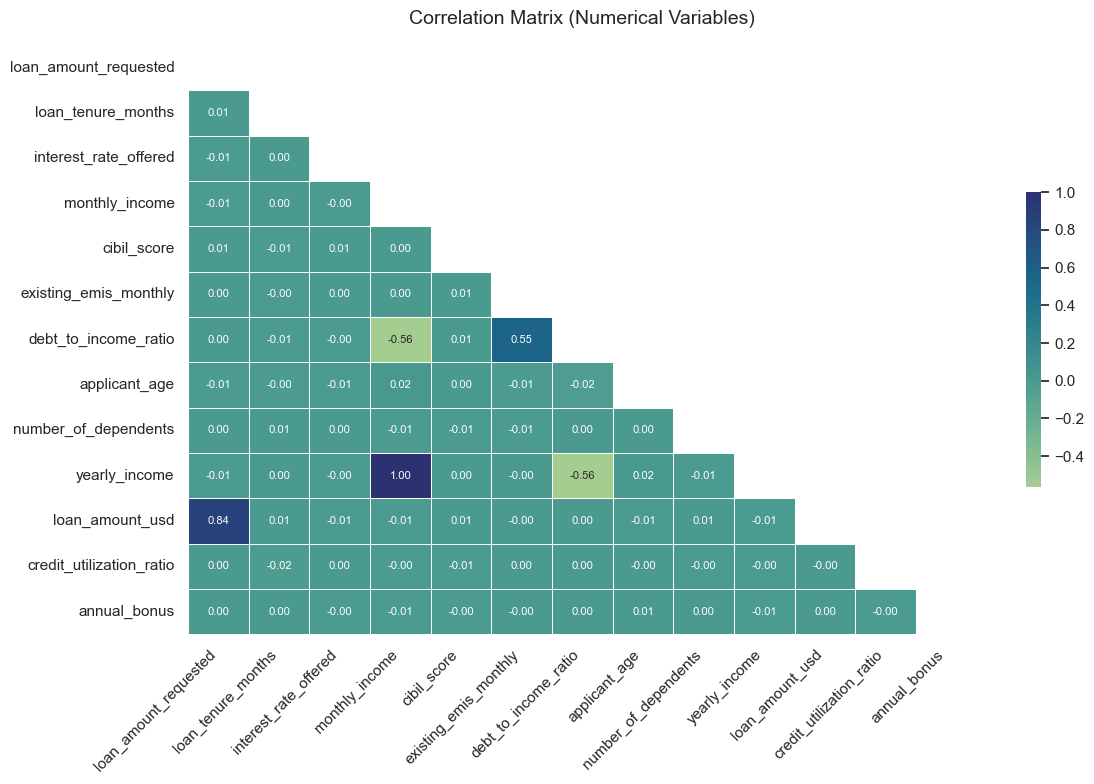

In [35]:
num_cols = [
    col for col in df_filtered.select_dtypes(include=['number']).columns
    if df_filtered[col].nunique() > 2
]

corr = df_filtered[num_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(12, 8))
sns.set_theme(style="white")

sns.heatmap(
    corr,
    mask=mask,
    cmap="crest",
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"shrink": .5},
    annot_kws={"size": 8}
)

plt.title("Correlation Matrix (Numerical Variables)", fontsize=14, pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


The only strong positive relationships observed are signs of data consistency: a perfect correlation between yearly_income and monthly_income, and a very strong correlation (r=0.84) between loan_amount_requested and loan_amount_usd.

As expected, higher monthly income strongly correlates with a lower debt income ratio, suggesting better financial health and potentially lower risk associated with existing debt burden. (Monthly Income vs. Debt to Income Ratio r= -0.56)

An applicant's income level does not linearly determine their credit score; other factors (like payment history) are the primary drivers of the score. (Income vs. Credit Score r=0.01)

Most other pairs have correlations close to zero, which shows that these variables have limited linear predictive power when considered individually against other features. Any true relationships might be non-linear and require more complex modeling techniques.

### 9.2 Temporal Analysis

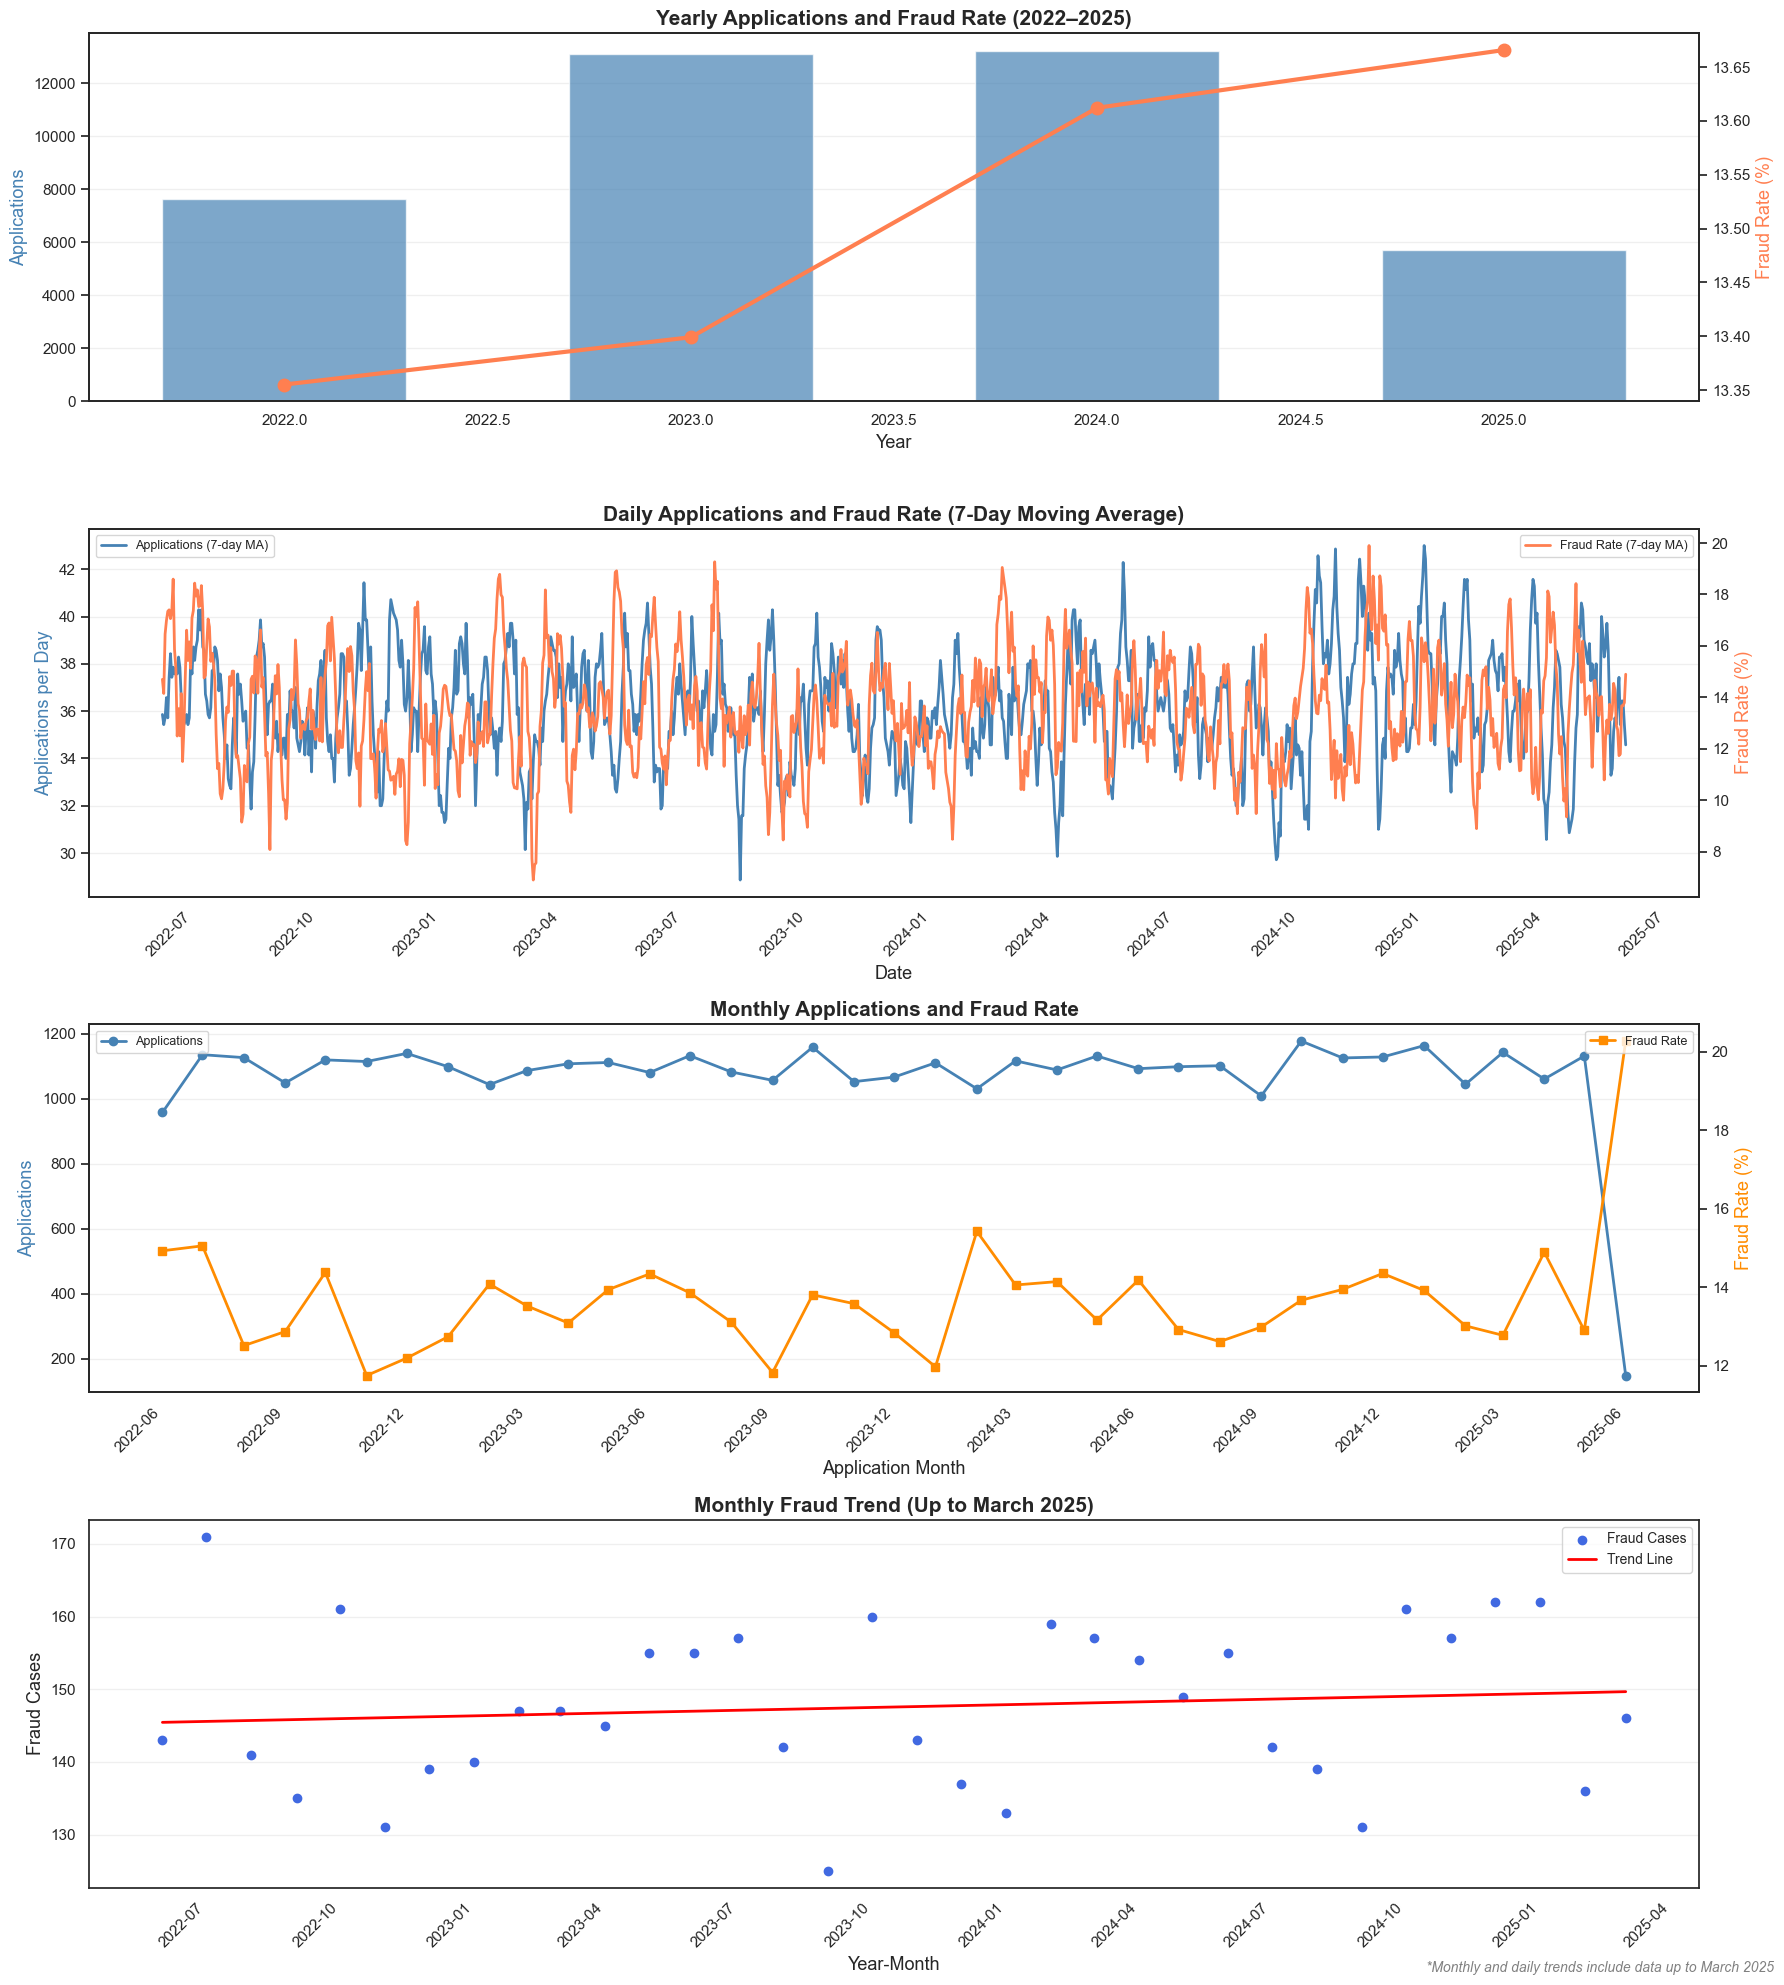

Total months with data: 37
Average fraud cases per month: 144.6
Median fraud cases per month: 146.0
Standard deviation: 22.2
Highest month: 2022-07 (171 cases)
Lowest month: 2025-06 (30 cases)


In [36]:
df_filtered['application_date'] = pd.to_datetime(df_filtered['application_date'])

yearly_data = (
    df_filtered.groupby(df_filtered['application_date'].dt.year)['fraud_flag']
    .agg(['sum', 'count'])
)
yearly_data['fraud_rate'] = (yearly_data['sum'] / yearly_data['count']) * 100

monthly_data = (
    df_filtered.groupby(df_filtered['application_date'].dt.to_period('M'))['fraud_flag']
    .agg(['sum', 'count'])
)
monthly_data.index = monthly_data.index.to_timestamp()
monthly_data['fraud_rate'] = (monthly_data['sum'] / monthly_data['count']) * 100

daily_data = (
    df_filtered.groupby('application_date')['fraud_flag']
    .agg(['sum', 'count'])
    .rename(columns={'sum': 'fraud_cases', 'count': 'applications'})
)
daily_data['fraud_rate'] = (daily_data['fraud_cases'] / daily_data['applications']) * 100
daily_data['applications_ma7'] = daily_data['applications'].rolling(7, center=True).mean()
daily_data['fraud_rate_ma7'] = daily_data['fraud_rate'].rolling(7, center=True).mean()

fig, axes = plt.subplots(4, 1, figsize=(18, 20))
plt.subplots_adjust(hspace=0.4)

ax1 = axes[0]
ax1_twin = ax1.twinx()

ax1.bar(yearly_data.index, yearly_data['count'], color='steelblue', alpha=0.7, width=0.6)
ax1_twin.plot(yearly_data.index, yearly_data['fraud_rate'], color='coral',
              marker='o', linewidth=3, markersize=9)

ax1.set_title('Yearly Applications and Fraud Rate (2022–2025)', fontsize=15, fontweight='bold')
ax1.set_xlabel('Year', fontsize=13)
ax1.set_ylabel('Applications', color='steelblue', fontsize=13)
ax1_twin.set_ylabel('Fraud Rate (%)', color='coral', fontsize=13)
ax1.grid(axis='y', alpha=0.3)

ax2 = axes[1]
ax2_twin = ax2.twinx()

ax2.plot(daily_data.index, daily_data['applications_ma7'],
         color='steelblue', linewidth=2, label='Applications (7-day MA)')
ax2_twin.plot(daily_data.index, daily_data['fraud_rate_ma7'],
              color='coral', linewidth=2, label='Fraud Rate (7-day MA)')

ax2.set_title('Daily Applications and Fraud Rate (7-Day Moving Average)',
              fontsize=15, fontweight='bold')
ax2.set_xlabel('Date', fontsize=13)
ax2.set_ylabel('Applications per Day', color='steelblue', fontsize=13)
ax2_twin.set_ylabel('Fraud Rate (%)', color='coral', fontsize=13)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')
ax2.grid(axis='y', alpha=0.3)
ax2.legend(loc='upper left', fontsize=9)
ax2_twin.legend(loc='upper right', fontsize=9)


ax3 = axes[2]
ax3_twin = ax3.twinx()

ax3.plot(monthly_data.index, monthly_data['count'],
         color='steelblue', marker='o', linewidth=2, label='Applications')
ax3_twin.plot(monthly_data.index, monthly_data['fraud_rate'],
              color='darkorange', marker='s', linewidth=2, label='Fraud Rate')

ax3.set_title('Monthly Applications and Fraud Rate', fontsize=15, fontweight='bold')
ax3.set_xlabel('Application Month', fontsize=13)
ax3.set_ylabel('Applications', color='steelblue', fontsize=13)
ax3_twin.set_ylabel('Fraud Rate (%)', color='darkorange', fontsize=13)
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax3.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax3.xaxis.get_majorticklabels(), rotation=45, ha='right')
ax3.grid(axis='y', alpha=0.3)
ax3.legend(loc='upper left', fontsize=9)
ax3_twin.legend(loc='upper right', fontsize=9)


ax4 = axes[3]

monthly_data_clean = monthly_data[monthly_data.index <= '2025-03-31']

ax4.scatter(monthly_data_clean.index, monthly_data_clean['sum'],
            color='royalblue', label='Fraud Cases')

x = np.arange(len(monthly_data_clean))
z = np.polyfit(x, monthly_data_clean['sum'], 1)
p = np.poly1d(z)
ax4.plot(monthly_data_clean.index, p(x),
         color='red', linewidth=2, label='Trend Line')

ax4.set_title('Monthly Fraud Trend (Up to March 2025)', fontsize=15, fontweight='bold')
ax4.set_xlabel('Year-Month', fontsize=13)
ax4.set_ylabel('Fraud Cases', fontsize=13)
ax4.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax4.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax4.xaxis.get_majorticklabels(), rotation=45, ha='right')
ax4.grid(axis='y', alpha=0.3)
ax4.legend(fontsize=10)

fig.text(0.99, 0.01,
         '*Monthly and daily trends include data up to March 2025',
         ha='right', fontsize=10, style='italic', color='gray')

plt.tight_layout()
plt.show()

print(f"Total months with data: {len(monthly_data)}")
print(f"Average fraud cases per month: {monthly_data['sum'].mean():.1f}")
print(f"Median fraud cases per month: {monthly_data['sum'].median():.1f}")
print(f"Standard deviation: {monthly_data['sum'].std():.1f}")
print(f"Highest month: {monthly_data['sum'].idxmax().strftime('%Y-%m')} ({monthly_data['sum'].max():.0f} cases)")
print(f"Lowest month: {monthly_data['sum'].idxmin().strftime('%Y-%m')} ({monthly_data['sum'].min():.0f} cases)")





## 6. Preprocessing

This section focuses on preparing the dataset for predictive modeling.  
The following steps are covered:
1. Handle missing values 
2. Identify the target and define the problem type
3. Create new engineered features  
4. Encode categorical variables  
5. Split data into training and testing sets  
6. Balance the target variable using resampling methods


### 6.1 Handle missing values

In [37]:
# KNN Imputer (uses similar numeric features). Round to int and keep missing flag.
from sklearn.impute import KNNImputer

impute_feats = [
    'monthly_income','yearly_income','existing_emis_monthly',
    'debt_to_income_ratio','credit_utilization_ratio','applicant_age','cibil_score'
]
# ensure features present
impute_feats = [c for c in impute_feats if c in df_filtered.columns]

# Print summary before imputation
print("Missing 'number_of_dependents' before:", df_filtered['number_of_dependents'].isna().sum())
print("Value counts before (including NaN):")
print(df_filtered['number_of_dependents'].value_counts(dropna=False).sort_index())

# build matrix
impute_df = df_filtered[impute_feats + ['number_of_dependents']].copy()

# KNNImputer
knn = KNNImputer(n_neighbors=5)
imputed = knn.fit_transform(impute_df)
imputed_df = pd.DataFrame(imputed, columns=impute_df.columns, index=impute_df.index)

# take imputed dependents, round and cast to Int64
df_filtered['number_of_dependents_knn'] = imputed_df['number_of_dependents'].round().astype('Int64')

# preserve original missing indicator (from original column)
df_filtered['number_of_dependents_missing'] = df_filtered['number_of_dependents'].isna()

# create an imputed column to compare, do not overwrite original yet
df_filtered['number_of_dependents_imputed'] = df_filtered['number_of_dependents'].fillna(df_filtered['number_of_dependents_knn']).astype('Int64')

# Print summary after imputation
print("\nMissing after (imputed column):", df_filtered['number_of_dependents_imputed'].isna().sum())
print("Value counts after (imputed):")
print(df_filtered['number_of_dependents_imputed'].value_counts().sort_index())

print("\nDescribe before (non-missing):")
print(df_filtered['number_of_dependents'].dropna().describe())
print("\nDescribe after (imputed):")
print(df_filtered['number_of_dependents_imputed'].describe())


Missing 'number_of_dependents' before: 3996
Value counts before (including NaN):
number_of_dependents
0       6882
1       7260
2       7136
3       7250
4       7113
<NA>    3996
Name: count, dtype: Int64

Missing after (imputed column): 0
Value counts after (imputed):
number_of_dependents_imputed
0    6924
1    8170
2    9253
3    8127
4    7163
Name: count, dtype: Int64

Describe before (non-missing):
count     35641.0
mean     2.012682
std      1.406298
min           0.0
25%           1.0
50%           2.0
75%           3.0
max           4.0
Name: number_of_dependents, dtype: Float64

Describe after (imputed):
count     39637.0
mean     2.010975
std      1.353766
min           0.0
25%           1.0
50%           2.0
75%           3.0
max           4.0
Name: number_of_dependents_imputed, dtype: Float64


In [38]:
 #Fill monthly_income based on yearly_income
df_filtered["monthly_income"] = np.where(
    df_filtered["monthly_income"].isna(),
    df_filtered["yearly_income"] / 12,
    df_filtered["monthly_income"]
)

### 6.2 Target and Problem Type
Show relative class frequencies for "fraud_flag" to confirm this is a binary classification task and to check class imbalance.

In [39]:
target_col = "fraud_flag"

if target_col not in df_filtered.columns:
    print(f"Column '{target_col}' not found in df_filtered.")
else:
    counts = df_filtered[target_col].value_counts(dropna=False)
    n = int(counts.sum())
    pos = int(counts.get(1, 0))
    neg = int(counts.get(0, 0))
    phat = pos / n if n > 0 else np.nan

    # Wilson score 95% CI
    z = 1.96
    if n > 0:
        denom = 1 + (z**2) / n
        centre = (phat + (z**2) / (2 * n)) / denom
        half = (z * np.sqrt(phat * (1 - phat) / n + (z**2) / (4 * n**2))) / denom
        ci_low, ci_high = centre - half, centre + half
    else:
        ci_low, ci_high = (np.nan, np.nan)

    print(f"n = {n:,} | positives = {pos:,} | negatives = {neg:,}")
    print(f"Positive class proportion (fraud): {phat:.3f} ({phat*100:.2f}%)")
    print(f"95% Wilson CI: [{ci_low:.3f}, {ci_high:.3f}] ({ci_low*100:.2f}%, {ci_high*100:.2f}%)\n")

    # concise recommendations based on prevalence
    if phat < 0.05:
        imbalance_note = "Strong class imbalance (rare positive). Use precision/recall, PR-AUC, stratified splits, and consider resampling or class_weight."
    elif phat < 0.2:
        imbalance_note = "Moderate imbalance. Prefer recall/precision metrics, stratified splits and consider class weighting."
    else:
        imbalance_note = "Balance is acceptable, but still use stratified splits and monitor precision/recall."

    print("Recommendation:", imbalance_note)

n = 39,637 | positives = 5,351 | negatives = 34,286
Positive class proportion (fraud): 0.135 (13.50%)
95% Wilson CI: [0.132, 0.138] (13.17%, 13.84%)

Recommendation: Moderate imbalance. Prefer recall/precision metrics, stratified splits and consider class weighting.


### 6.3 Feature Engineering

We add new financial ratios and behavioral indicators that may improve fraud detection.

- **loan_to_income_ratio:** relationship between loan amount and applicant income  
- **emi_to_income_ratio:** proportion of existing EMIs to income  
- **income_plus_bonus:** total annual income including bonuses  
- **is_repeat_customer:** flag if the customer submitted more than one application


In [40]:
df_filtered["loan_to_income_ratio"] = df_filtered["loan_amount_usd"] / df_filtered["yearly_income"]
df_filtered["emi_to_income_ratio"] = df_filtered["existing_emis_monthly"] / df_filtered["monthly_income"]
df_filtered["income_plus_bonus"] = df_filtered["yearly_income"] + df_filtered["annual_bonus"]

df_filtered["is_repeat_customer"] = df_filtered["customer_id"].duplicated(keep=False).astype(int)

df_filtered.head()

,application_id,customer_id,application_date,loan_amount_requested,loan_tenure_months,interest_rate_offered,purpose_of_loan,employment_status,monthly_income,cibil_score,existing_emis_monthly,debt_to_income_ratio,property_ownership_status,residential_address,applicant_age,number_of_dependents,loan_type_Car Loan,loan_type_Education Loan,loan_type_Home Loan,loan_type_Personal Loan,gender_Male,gender_Other,yearly_income,loan_amount_usd,credit_utilization_ratio,annual_bonus,data_batch_id,fraud_flag,loan_type_sum,loan_type_label,gender_sum,number_of_dependents_knn,number_of_dependents_missing,number_of_dependents_imputed,loan_to_income_ratio,emi_to_income_ratio,income_plus_bonus,is_repeat_customer
0,acde818b-d1cc-4da4-9858-c2155ee2be85,CUST102632,2025-02-19,100000.0,60,11.27,Vehicle Purchase,Self-Employed,54900.0,633,1700.0,3.10,Jointly Owned,"288, Borde Ganj, Udupi-974980, Medininagar, Go...",39,4,0,1,0,0,0,0,658800.0,108000.0,0.424338,611.79,batch_20250926_A,0,1,Education,0,4,False,4,0.163934,0.030965,659411.79,1
1,75ab4a03-0d02-4ee4-9840-97486f64ec9e,CUST109462,2024-02-09,551000.0,360,12.14,Vehicle Purchase,Retired,47600.0,705,700.0,1.47,Owned,"664, Koshy Chowk, Rajahmundry 550800, Vadodara...",49,1,0,0,0,1,1,0,571200.0,595080.0,0.387727,300.12,batch_20250926_A,1,1,Personal,1,1,False,1,1.041807,0.014706,571500.12,1
2,f1170d68-b793-46e2-835a-2c1d58be9d9d,CUST105157,2025-05-10,440000.0,240,12.26,Business Expansion,Self-Employed,123000.0,750,5000.0,4.07,Rented,"H.No. 756, Solanki Ganj, Asansol-243947, Panch...",26,4,0,0,1,0,0,0,1476000.0,475200.0,0.363311,195884.39,batch_20250926_A,0,1,Home,0,4,False,4,0.321951,0.040650,1671884.39,1
3,2ccd4175-9bee-464f-b321-22645c778d8e,CUST103892,2024-09-09,1075000.0,12,12.77,Wedding,Business Owner,30000.0,732,6500.0,21.67,Owned,"27/711, Barad Ganj, Bhilai 678823, Karimnagar,...",36,2,1,0,0,0,0,0,360000.0,1161000.0,0.743246,9669.89,batch_20250926_A,0,1,Car,0,2,False,2,3.225000,0.216667,369669.89,1
4,645a4f5b-3382-4624-8496-801147ca1bc3,CUST114147,2023-10-14,379000.0,120,10.56,Wedding,Retired,109800.0,711,2000.0,1.82,Rented,"716, Uppal Zila, Thiruvananthapuram-263026, Ma...",52,4,1,0,0,0,0,1,1317600.0,409320.0,0.442568,1646.28,batch_20250926_A,0,1,Car,1,4,False,4,0.310656,0.018215,1319246.28,1


### 6.4 Encode Categorical Variables

The existing gender and loan type flags are unreliable.  
We will exclude them and create a more robust encoding for other categorical columns.

Categorical columns used:
- `employment_status`
- `purpose_of_loan`
- `property_ownership_status`

Encoding method:
- **One-Hot Encoding** for nominal variables

In [41]:
from sklearn.preprocessing import OneHotEncoder

# Drop unreliable dummy variables
cols_to_drop = [
    "gender_Male", "gender_Other",
    "loan_type_Car Loan", "loan_type_Education Loan",
    "loan_type_Home Loan", "loan_type_Personal Loan"
]
df_filtered = df_filtered.drop(columns=cols_to_drop, errors="ignore")

# Select reliable categorical columns
categorical_cols = [
    "employment_status", "purpose_of_loan",
    "property_ownership_status"
]

# Apply one-hot encoding
encoder = OneHotEncoder(drop="first", sparse_output=False)
encoded = encoder.fit_transform(df_filtered[categorical_cols])

encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(categorical_cols))
df_filtered = pd.concat([df_filtered.drop(columns=categorical_cols), encoded_df], axis=1)


In [42]:
df_filtered.head()

,application_id,customer_id,application_date,loan_amount_requested,loan_tenure_months,interest_rate_offered,monthly_income,cibil_score,existing_emis_monthly,debt_to_income_ratio,residential_address,applicant_age,number_of_dependents,yearly_income,loan_amount_usd,credit_utilization_ratio,annual_bonus,data_batch_id,fraud_flag,loan_type_sum,loan_type_label,gender_sum,number_of_dependents_knn,number_of_dependents_missing,number_of_dependents_imputed,loan_to_income_ratio,emi_to_income_ratio,income_plus_bonus,is_repeat_customer,employment_status_Retired,employment_status_Salaried,employment_status_Self-Employed,employment_status_Student,employment_status_Unemployed,purpose_of_loan_Debt Consolidation,purpose_of_loan_Education,purpose_of_loan_Home Renovation,purpose_of_loan_Medical Emergency,purpose_of_loan_Vehicle Purchase,purpose_of_loan_Wedding,property_ownership_status_Owned,property_ownership_status_Rented
0,acde818b-d1cc-4da4-9858-c2155ee2be85,CUST102632,2025-02-19,100000.0,60.0,11.27,54900.0,633.0,1700.0,3.10,"288, Borde Ganj, Udupi-974980, Medininagar, Go...",39.0,4,658800.0,108000.0,0.424338,611.79,batch_20250926_A,0.0,1.0,Education,0.0,4,False,4,0.163934,0.030965,659411.79,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,75ab4a03-0d02-4ee4-9840-97486f64ec9e,CUST109462,2024-02-09,551000.0,360.0,12.14,47600.0,705.0,700.0,1.47,"664, Koshy Chowk, Rajahmundry 550800, Vadodara...",49.0,1,571200.0,595080.0,0.387727,300.12,batch_20250926_A,1.0,1.0,Personal,1.0,1,False,1,1.041807,0.014706,571500.12,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
2,f1170d68-b793-46e2-835a-2c1d58be9d9d,CUST105157,2025-05-10,440000.0,240.0,12.26,123000.0,750.0,5000.0,4.07,"H.No. 756, Solanki Ganj, Asansol-243947, Panch...",26.0,4,1476000.0,475200.0,0.363311,195884.39,batch_20250926_A,0.0,1.0,Home,0.0,4,False,4,0.321951,0.040650,1671884.39,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,2ccd4175-9bee-464f-b321-22645c778d8e,CUST103892,2024-09-09,1075000.0,12.0,12.77,30000.0,732.0,6500.0,21.67,"27/711, Barad Ganj, Bhilai 678823, Karimnagar,...",36.0,2,360000.0,1161000.0,0.743246,9669.89,batch_20250926_A,0.0,1.0,Car,0.0,2,False,2,3.225000,0.216667,369669.89,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
4,645a4f5b-3382-4624-8496-801147ca1bc3,CUST114147,2023-10-14,379000.0,120.0,10.56,109800.0,711.0,2000.0,1.82,"716, Uppal Zila, Thiruvananthapuram-263026, Ma...",52.0,4,1317600.0,409320.0,0.442568,1646.28,batch_20250926_A,0.0,1.0,Car,1.0,4,False,4,0.310656,0.018215,1319246.28,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0


### 6.5 Split Training and Testing Sets

We use an 80/20 split to evaluate model performance on unseen data.

In [47]:
from sklearn.model_selection import train_test_split

X = df_filtered.drop(columns=[target_col, "application_id", "customer_id"])
y = df_filtered[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")

ValueError: Input y contains NaN.